# Zurich Airpot analysis

In [88]:
# Import necessary libraries
import pandas as pd
import glob
import  matplotlib.pyplot as plt

In [64]:
# Load and concatenate all CSV files from the specified folder
file_paths = glob.glob("./data/zurich*.csv")
df = pd.concat((pd.read_csv(file) for file in file_paths), ignore_index=True)
df

,Date,Type,LocalAirport,ForeignAirport,Airline,Status,Planned,Expected
0,2024-10-28,arrival,Zurich,Geneva,swiss,Landed,21:05,20:58
1,2024-10-28,arrival,Zurich,Berlin,swiss,Landed,21:05,21:03
2,2024-10-28,arrival,Zurich,Paris CDG,swiss,Landed,21:10,21:07
3,2024-10-28,arrival,Zurich,Venice,swiss,Landed,21:15,21:07
4,2024-10-28,arrival,Zurich,Brussels,swiss,Landed,21:20,21:16
...,...,...,...,...,...,...,...,...
8121,2024-11-07,departure,Zurich,Madrid,swiss,Departed,06:50,NaN
8122,2024-11-07,departure,Zurich,Cluj-Napoca,swiss,Departed,06:55,NaN
8123,2024-11-07,departure,Zurich,Vilnius,swiss,Departed,06:55,NaN
8124,2024-11-07,departure,Zurich,Amsterdam,klm,Departed,06:55,NaN


In [65]:
# Fill NaN values in Expected column with values from Planned
df['Expected'].isnull().sum()

np.int64(2335)

In [67]:
df['Expected'].fillna(df['Planned'])
df['Expected'].isnull().sum()

np.int64(0)

In [68]:
# Convert Planned and Expected columns to datetime format for calculations
#df['Date'] = pd.to_datetime(df['Date'])
df['PlannedDate'] = pd.to_datetime(df['Date'] + " " + df['Planned'])
df['ExpectedDate'] = pd.to_datetime(df['Date'] + " " + df['Expected'])
df.sort_values(by='Date', ascending=True).head(5)

,Date,Type,LocalAirport,ForeignAirport,Airline,Status,Planned,Expected,PlannedDate,ExpectedDate
842,2024-10-21,arrival,Zurich,Copenhagen,swiss,Landed,11:30,11:53,2024-10-21 11:30:00,2024-10-21 11:53:00
876,2024-10-21,arrival,Zurich,Malaga,swiss,Landed,09:10,09:18,2024-10-21 09:10:00,2024-10-21 09:18:00
875,2024-10-21,arrival,Zurich,Kos,edelweiss,Landed,12:45,13:05,2024-10-21 12:45:00,2024-10-21 13:05:00
874,2024-10-21,arrival,Zurich,Heraklion,edelweiss,Landed,12:40,13:03,2024-10-21 12:40:00,2024-10-21 13:03:00
873,2024-10-21,arrival,Zurich,Munich,lufthansa_neu,Landed,12:40,13:07,2024-10-21 12:40:00,2024-10-21 13:07:00


In [79]:
# Filter data for the last two weeks only
two_weeks_ago = pd.to_datetime("today") - pd.Timedelta(weeks=2)
df_last_two_weeks = df[pd.to_datetime(df['Date']) >= two_weeks_ago].copy()
df_last_two_weeks.sort_values(by='Date', ascending=True).head(5)

,Date,Type,LocalAirport,ForeignAirport,Airline,Status,Planned,Expected,PlannedDate,ExpectedDate,Delay
0,2024-10-28,arrival,Zurich,Geneva,swiss,Landed,21:05,20:58,2024-10-28 21:05:00,2024-10-28 20:58:00,-7.0
410,2024-10-28,departure,Zurich,Oslo OSL,swiss,Departed,15:45,16:05,2024-10-28 15:45:00,2024-10-28 16:05:00,20.0
411,2024-10-28,departure,Zurich,Istanbul SAW,pegasus,Departed,16:10,16:15,2024-10-28 16:10:00,2024-10-28 16:15:00,5.0
412,2024-10-28,departure,Zurich,Porto,tap,Departed,16:20,16:20,2024-10-28 16:20:00,2024-10-28 16:20:00,0.0
413,2024-10-28,departure,Zurich,Madrid,swiss,Departed,16:20,16:25,2024-10-28 16:20:00,2024-10-28 16:25:00,5.0


In [80]:
# Separate the data by Type (Arrivals and Departures)
arrivals_df = df_last_two_weeks[df_last_two_weeks['Type'] == 'arrival']
departures_df = df_last_two_weeks[df_last_two_weeks['Type'] == 'departure']

In [81]:
### Question 1: Origin Analysis
# Find the top five most frequent origins of arriving flights

origin_counts = arrivals_df.groupby('ForeignAirport').size().nlargest(5).reset_index(name='Frequency')
print("Top five most frequent origins for arriving flights over the past two weeks:")
origin_counts

Top five most frequent origins for arriving flights over the past two weeks:


,ForeignAirport,Frequency
0,London LHR,83
1,Berlin,80
2,Amsterdam,74
3,Frankfurt,55
4,Vienna,54


<Figure size 1000x600 with 0 Axes>

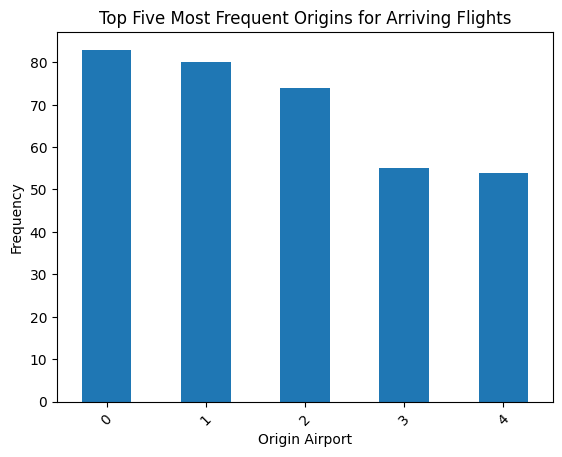

In [97]:
### Plot the histogram for most frequent origins
plt.figure(figsize=(10, 6))
origin_counts.plot(kind='bar', legend=False)  # Use pandas plotting
plt.title("Top Five Most Frequent Origins for Arriving Flights")
plt.xlabel("Origin Airport")
plt.ylabel("Frequency")
plt.xticks(rotation=45) 
plt.show()

In [86]:
### Question 2: Airline Frequency
# Find the airlines with the highest frequency of arrivals

airline_counts = arrivals_df.groupby('Airline').size().nlargest(5).reset_index(name='Frequency')
print("Top five airlines with the highest frequency of arrivals:")
airline_counts

Top five airlines with the highest frequency of arrivals:


,Airline,Frequency
0,swiss,1154
1,edelweiss,134
2,euro,64
3,lufthansa_neu,63
4,british,55


<Figure size 1000x600 with 0 Axes>

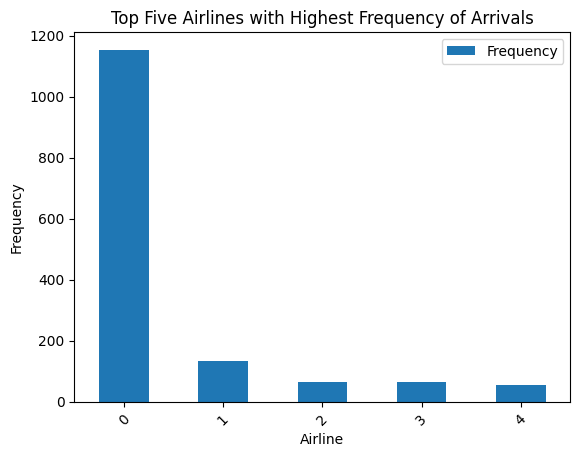

In [98]:
# Plot the histogram for airline frequency
plt.figure(figsize=(10, 6))
airline_counts.plot(kind='bar')
plt.title("Top Five Airlines with Highest Frequency of Arrivals")
plt.xlabel("Airline")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [87]:
### Question 3: Punctuality Metrics
# Calculate delay as the difference between Expected and Planned times
df_last_two_weeks['Delay'] = ((df_last_two_weeks['ExpectedDate'] - df_last_two_weeks['PlannedDate'])
                              .dt.total_seconds() / 60)  # Delay in minutes

# Average delay for arrivals and departures at Zurich
arrival_delays = arrivals_df['Delay'].mean()
departure_delays = departures_df['Delay'].mean()

print(f"Average delay of arriving flights: {arrival_delays:.2f} minutes")
print(f"Average delay of departing flights: {departure_delays:.2f} minutes")

# Comparison of delay across airports (if multiple airport codes are used in LocalAirport column)
punctuality_metrics = df.groupby(['LocalAirport', 'Type'])['Delay'].mean().reset_index()
punctuality_metrics.columns = ['Airport', 'FlightType', 'AverageDelay']

print("Average delay by airport and flight type:")
display(punctuality_metrics)

Average delay of arriving flights: 2.90 minutes
Average delay of departing flights: 7.01 minutes
Average delay by airport and flight type:


,Airport,FlightType,AverageDelay
0,Zurich,arrival,5.032201
1,Zurich,departure,7.410263


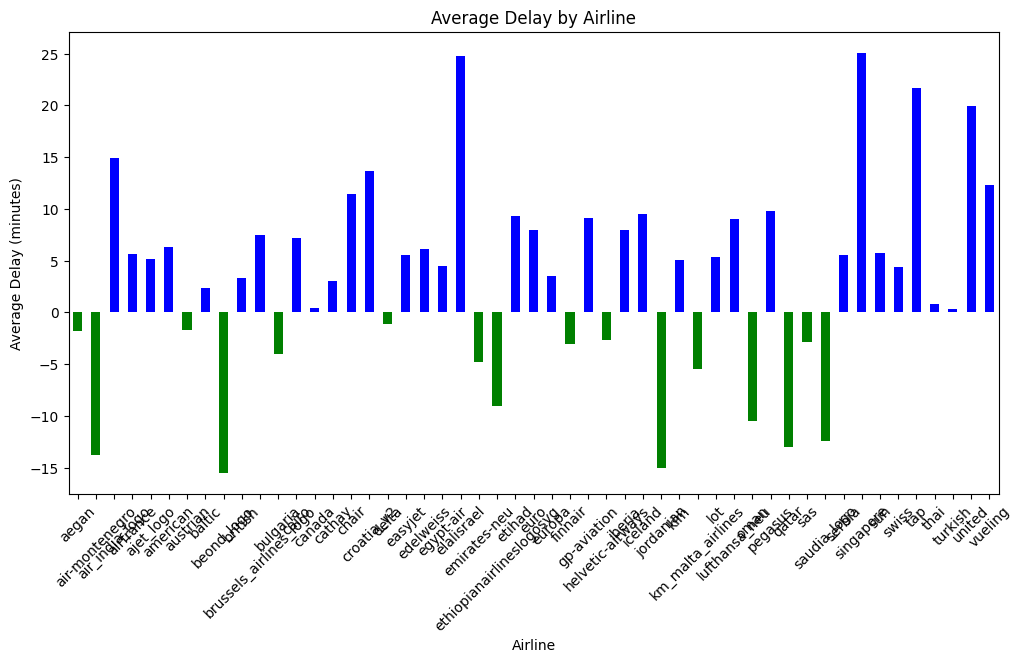

In [101]:
# Calculate average delay for each airline
average_delay_by_airline = df_last_two_weeks.groupby('Airline')['Delay'].mean()

# Plot average delay for each airline
plt.figure(figsize=(12, 6))
colors = ['green' if delay < 0 else 'blue' for delay in average_delay_by_airline]
average_delay_by_airline.plot(kind='bar', color=colors)
plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()